# Boltzmann Wealth Model

## What This Model Does

This notebook implements the **Boltzmann Wealth Model**, a classic agent-based model that simulates wealth distribution through random exchanges between agents.

Each agent starts with **1 unit of wealth**. At every step, each agent randomly gives 1 unit of wealth to another agent (if they have any). Despite starting from perfectly equal conditions, the model produces a **highly unequal wealth distribution** over time.

This emergent inequality is known as the **Boltzmann-Gibbs distribution**, and it arises purely from random interactions, without any initial advantage for any agent.

## Mesa Features Used
- `mesa.Agent` — defines individual agent behavior
- `mesa.Model` — manages the simulation world
- `AgentSet.shuffle_do()` — activates agents in random order each step
- `Agent.create_agents()` — batch-creates multiple agents at once
- `Model.run_for()` — runs the model for a fixed number of steps

## Key Insight
Even when every agent starts with the same wealth and follows the same rules, **inequality emerges naturally** from random interactions.

In [1]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

## Define the agent
An **Agent** represents one individual in the simulation. Each agent is a person who starts with 1 unit of wealth.

Key concept: `super().__init__(model)` is a required call that registers the agent with the model and assigns it a unique ID automatically.

In [2]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

## Define the Model

The **Model** is the game world that contains all agents. 

The `rng` parameter sets a random seed. 
If you pass the same seed (e.g., `rng=42`), the simulation produces the **exact same results every time**  *(the challenge problem)*.

In [ ]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        # Create agents
        MoneyAgent.create_agents(model=self, n=n)

## Adding Behavior — say_hi()

say_hi(): each agent introduces itself.

**What is `shuffle_do()`?** 
It randomly reorders all agents, then calls the specified method on each one.*(The challenge problem)*
Important: the string passed to `shuffle_do()` must exactly match the method name defined in the agent class.

In [ ]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's attribute and set the initial values.
        self.wealth = 1

    def say_hi(self):
        # The agent's step will go here.
        # For demonstration purposes we will print the agent's unique_id
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n

        # Create n agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function pseudo-randomly reorders the list of agent objects
        # then iterates through calling the function passed in as the parameter
        self.agents.shuffle_do("say_hi")

## Set Seed
- `starter_model` uses `rng=None` -> agent order changes every run
- `starter_model1` uses `rng=42` -> agent order is identical every run

**What I learned:** Setting a fixed seed is essential for reproducible research.

In [ ]:
starter_model = MoneyModel(10)
starter_model.step()

# Challenge: Change the seed from None to a number like 42 and see the impact
# the name of each agent would be the same in every run.
starter_model1 = MoneyModel(10,42)
starter_model1.step()

Hi, I am an agent, you can call me 5.
Hi, I am an agent, you can call me 8.
Hi, I am an agent, you can call me 7.
Hi, I am an agent, you can call me 2.
Hi, I am an agent, you can call me 3.
Hi, I am an agent, you can call me 10.
Hi, I am an agent, you can call me 6.
Hi, I am an agent, you can call me 4.
Hi, I am an agent, you can call me 9.
Hi, I am an agent, you can call me 1.
/n
Hi, I am an agent, you can call me 8.
Hi, I am an agent, you can call me 4.
Hi, I am an agent, you can call me 3.
Hi, I am an agent, you can call me 9.
Hi, I am an agent, you can call me 6.
Hi, I am an agent, you can call me 7.
Hi, I am an agent, you can call me 10.
Hi, I am an agent, you can call me 5.
Hi, I am an agent, you can call me 1.
Hi, I am an agent, you can call me 2.


### Challenge: shuffle_do vs do

Changing `shuffle_do` to `do` activates agents in a fixed, increasing order every step.
- With `shuffle_do`: random order -> fairer simulation
- With `do`: agent 0 always acts first -> can introduce systematic bias

## Printing Wealth

`say_wealth()`: each agent reports its current wealth. 

This verifies agents can track and report their wealth correctly before we add the real exchange logic.

In [38]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def say_wealth(self):
        # The agent's step will go here.
        # FIXME: need to print the agent's wealth
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")
        print(f"My wealth is{self.wealth}.")

class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n

        # Create n agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function pseudo-randomly reorders the list of agent objects
        # then iterates through calling the function passed in as the parameter
        self.agents.shuffle_do("say_wealth")

In [39]:
# Fixme: Create the model object, and run it
model_wealth = MoneyModel(12)
model_wealth.step()

Hi, I am an agent, you can call me 1.
My wealth is1.
Hi, I am an agent, you can call me 5.
My wealth is1.
Hi, I am an agent, you can call me 12.
My wealth is1.
Hi, I am an agent, you can call me 11.
My wealth is1.
Hi, I am an agent, you can call me 10.
My wealth is1.
Hi, I am an agent, you can call me 7.
My wealth is1.
Hi, I am an agent, you can call me 6.
My wealth is1.
Hi, I am an agent, you can call me 4.
My wealth is1.
Hi, I am an agent, you can call me 3.
My wealth is1.
Hi, I am an agent, you can call me 9.
My wealth is1.
Hi, I am an agent, you can call me 8.
My wealth is1.
Hi, I am an agent, you can call me 2.
My wealth is1.


## Wealth Exchange

Each agent follows a simple rule:
1. **Check** if they have any wealth (`wealth > 0`)
2. **Pick** a random other agent
3. **Give** that agent 1 unit of wealth, deducting 1 from themselves

**Why check `wealth > 0`?** 
An agent with 0 wealth cannot give anything. Without this check, agents could go into debt.

**Why use `self.random.choice()`?** 
Using the model's random generator ensures results are reproducible when a seed is set.

This simple rule, applied to many agents over many steps, produces a **Boltzmann distribution** — the same mathematical pattern seen in thermodynamics and real-world wealth inequality.

In [40]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n

        # Create agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter
        self.agents.shuffle_do("exchange")

## Running the Model

Create a model with 10 agents and run it for 30 steps.

In [42]:
model = MoneyModel(10)  # Tells the model to create 10 agents
for _ in range(30):  # Runs the model for 30 steps;
    model.step()

# Note: An underscore is common convention for a variable that is not used.

## Visualizing Wealth Distribution (One Run)

- Extract the final wealth of each agent and plot a histogram.

- `[a.wealth for a in model.agents]` is a compact way to collect one attribute from all agents at once.

- With only 10 agents and 30 steps, the distribution is noisy. The pattern becomes clearer with more runs.

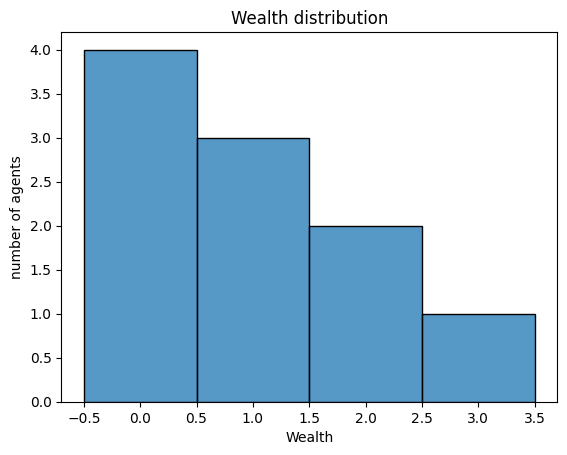

In [43]:
agent_wealth = [a.wealth for a in model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation

## Running 100 Simulations

Use a **nested loop** to run the model 100 times:

- **Outer loop** (`range(100)`): runs 100 independent simulations
- **Inner loop** (`for agent in model.agents`): collects each agent's final wealth

Total data points: 100 runs × 10 agents = **1,000 wealth values**

With 1,000 data points, the histogram clearly shows an **exponential decay** — most agents end up poor while a few accumulate significant wealth. This is the Boltzmann distribution, emerging even though every agent started equal and followed identical rules.


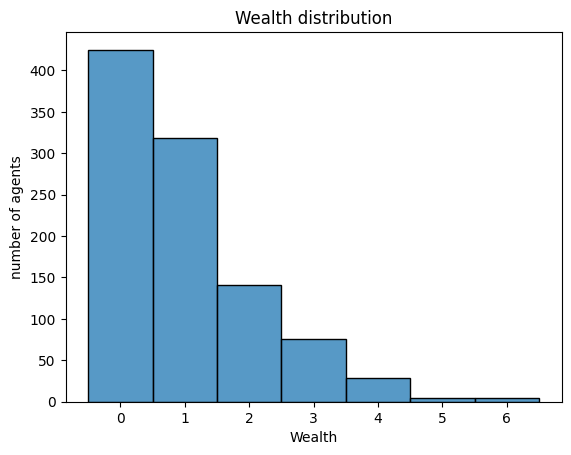

In [ ]:
all_wealth = []
# This runs the model 100 times, each model executing 30 steps.
for _ in range(100):
    # Run the model
    model = MoneyModel(10)
    model.run_for(30)

    # Store the results, each time collect 10 agents' wealth
    for agent in model.agents:
        all_wealth.append(agent.wealth)

# Use seaborn
g = sns.histplot(all_wealth, discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

## Colletcing Data

In [3]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

# Import Cell Agent and OrthogonalMooreGrid
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid

In [4]:
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1

    # Move Function
    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        cellmates = [
            a for a in self.cell.agents if a is not self
        ]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, width, height, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        # Instantiate an instance of Moore neighborhood space
        self.grid = OrthogonalMooreGrid((width, height), torus=True, random=self.random)

        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

In [5]:
model = MoneyModel(100, 10, 10)
model.run_for(20)
# Let's make sure it worked
print(len(model.agents))

100


In [20]:
# Add function for model level collection
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    n = model.num_agents
    B = sum(xi * (n - i) for i, xi in enumerate(x)) / (n * sum(x))
    return 1 + (1 / n) - 2 * B


class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell
        self.wealth = 1

    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        cellmates = [a for a in self.cell.agents if a is not self]

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, width, height, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        self.grid = OrthogonalMooreGrid((width, height), torus=True, random=self.random)
        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, # Model-level variable
            agent_reporters={"Wealth": "wealth"} # Agent-level variable
        )

        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        # Collect data each step
        self.datacollector.collect(self)
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

In [21]:
model = MoneyModel(100, 10, 10)
model.run_for(100)

## Analyzing MoneyModel Data

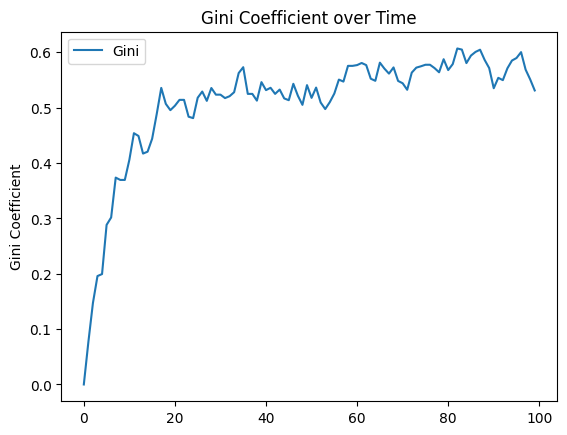

In [22]:
# Extract MoneyModel data in a Pandas dataframe
gini = model.datacollector.get_model_vars_dataframe()
g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient");

## Exercise
- **Display just the data to see the format**

In [23]:
print(model.datacollector.get_model_vars_dataframe())

      Gini
0   0.0000
1   0.0768
2   0.1472
3   0.1958
4   0.1994
..     ...
95  0.5896
96  0.6002
97  0.5686
98  0.5510
99  0.5310

[100 rows x 1 columns]


- **Comment on the collect method on the step function and see the impact**

    The dataframe would be empty and there's not output in the graph

- **Increase agents and time to see how the plot changes**

    More agent will make the graph becomes *smoother*, since individual's inpact on the whole group will decrease.

       Gini
0    0.0000
1    0.0000
2    0.0000
3    0.0768
4    0.1496
..      ...
195  0.5592
196  0.5592
197  0.5816
198  0.5816
199  0.5648

[200 rows x 1 columns]


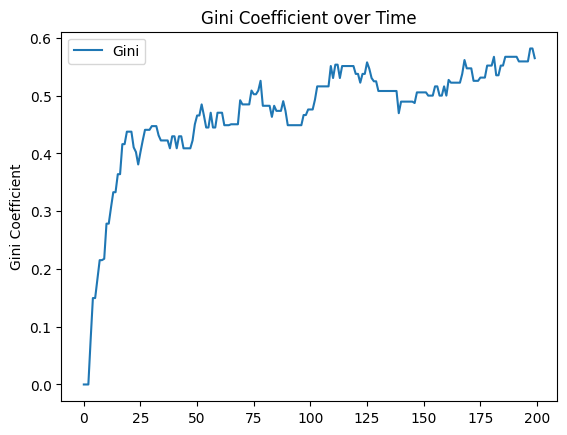

In [25]:
model = MoneyModel(50, 10, 10)
model.run_for(200)
# Extract MoneyModel data in a Pandas dataframe
gini = model.datacollector.get_model_vars_dataframe()
g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient");
print(model.datacollector.get_model_vars_dataframe())

## Analyzing an MoneyAgent Data

In [10]:
agent_wealth = model.datacollector.get_agent_vars_dataframe()
agent_wealth.head()

Wealth
Step AgentID        
1.0  1             1
     2             1
     3             1
     4             1
     5             1

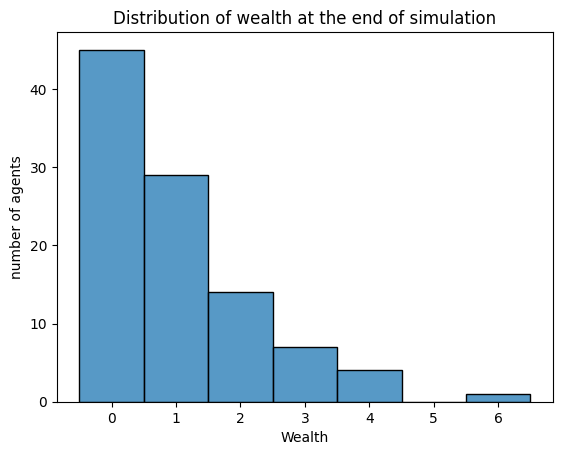

In [26]:
last_step = agent_wealth.index.get_level_values("Step").max()  # Get the last step
end_wealth = agent_wealth.xs(last_step, level="Step")[
    "Wealth"
]  # Get the wealth of each agent at the last step
# Create a histogram of wealth at the last step
g = sns.histplot(end_wealth, discrete=True)
g.set(
    title="Distribution of wealth at the end of simulation",
    xlabel="Wealth",
    ylabel="number of agents",
);

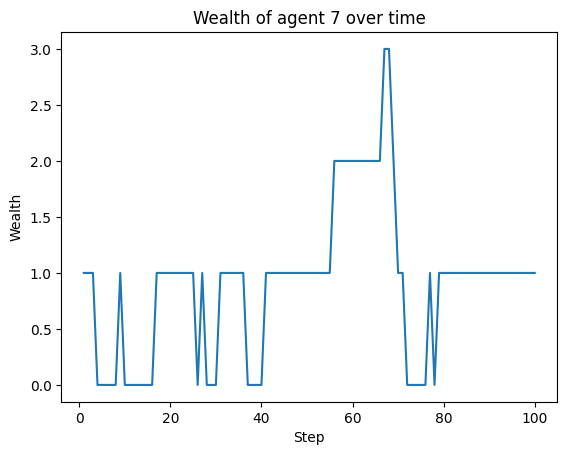

In [27]:
# Get the wealth of agent 7 over time
one_agent_wealth = agent_wealth.xs(7, level="AgentID")

# Plot the wealth of agent 7 over time
g = sns.lineplot(data=one_agent_wealth, x="Step", y="Wealth")
g.set(title="Wealth of agent 7 over time");

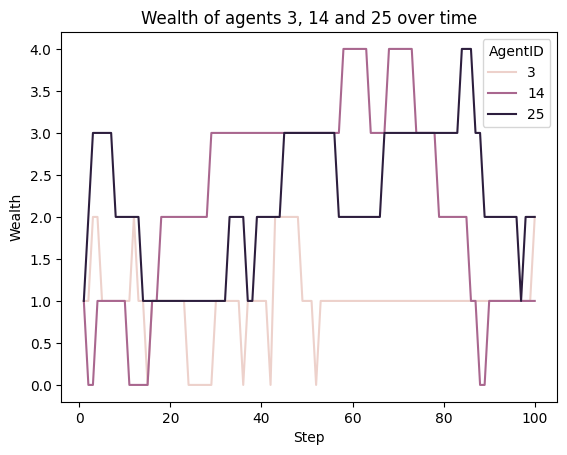

In [28]:
agent_list = [3, 14, 25]

# Get the wealth of multiple agents over time
multiple_agents_wealth = agent_wealth[
    agent_wealth.index.get_level_values("AgentID").isin(agent_list)
]
# Plot the wealth of multiple agents over time
g = sns.lineplot(data=multiple_agents_wealth, x="Step", y="Wealth", hue="AgentID")
g.set(title="Wealth of agents 3, 14 and 25 over time");

[Text(0.5, 1.0, 'Average wealth over time')]

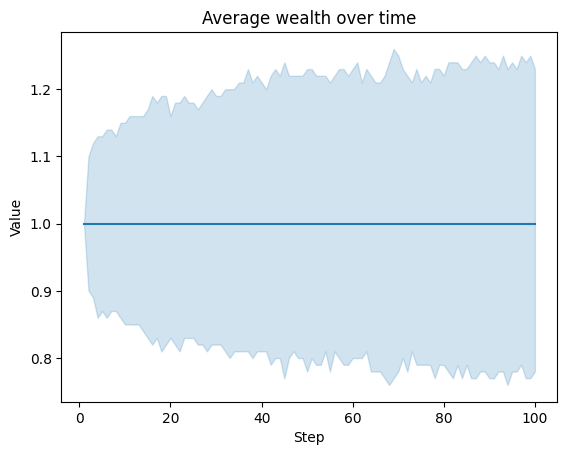

In [29]:
# Transform the data to a long format
agent_wealth_long = agent_wealth.T.unstack().reset_index()
agent_wealth_long.columns = ["Step", "AgentID", "Variable", "Value"]
agent_wealth_long.head(3)

# Plot the average wealth over time
g = sns.lineplot(data=agent_wealth_long, x="Step", y="Value", errorbar=("ci", 95))
g.set(title="Average wealth over time")

In [30]:
# save the model data (stored in the pandas gini object) to CSV
gini.to_csv("model_data.csv")

# save the agent data (stored in the pandas agent_wealth object) to CSV
agent_wealth.to_csv("agent_data.csv")